# Optimal Policy in datasets

Objective: For each workload, compute at each buffersize, what would be the Optimal Policy performance to reach the optimal buffersize value, i.e at the SLA tipping point.

A first implementation for an actions space [-1, 1] and a STOP when the tipping point is reach (not even a lonely STAY action...).

To see later: computation in case of a larger actions space and with N stay actions at last at the tipping point....

Sources:
+ workloads_train_10.pickle +  workloads_test_10.pickle
+ workloads_c098_train_11. + workloads_c098_test_11.pickle
+ original_dataset_gaussian_uniform_with_original_columns12gu.pickle



In [1]:
import sys
sys.path.append('../pkg')

import pandas as pd
from datasource.dataframes.obs_samples_dataframes import ObsSamplesDF

2025-12-03 07:53:56.992846: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [112]:
obsdf = ObsSamplesDF(version="16")
picklefiles="../workloads_legacy_full_16"
df = obsdf.loadFromPickle(picklefiles)

dftipping = df[df["sla_tipping01"]==2][["sla_tipping01", "combined_column"]].drop_duplicates()
dftipping.reset_index(drop=True, inplace=True)
print("LIST", dftipping.to_string(index=True))
print()

workload = "V10 40 1.0 12 Un" # 64"V9 5 0.1 2 Ga" #63"V10 50 1.0 3 Pa" #62"V9 40 0.3 2 Ga" #0"V10 40 1.0 12 Un" #2"V9 40 1.0 12 Un" #10"V10 40 1.0 7 Un
df.loc[df["combined_column"]==workload, "buf_size_mb"] = df.apply(lambda row: int(row["buf_size"])/1024/1024 , axis=1)
#df[df["combined_column"]==workload]["sla_tipping01"].tolist()
#df[df["combined_column"]==workload]["buf_size_idx"].tolist()


new_columns = ["OP_USLA", "OP_CRAM", "OP_OB_CRAM", "OP_OB_USLA"]

#df.loc[df["combined_column"]==workload, "buf_size_idx","OP_USLA"]
dfresults = df[df["combined_column"]==workload][["buf_size_idx","sla_tipping01", "buf_size_mb", "sysbench_filtered.latency_mean"]+new_columns]
dfresults.reset_index(drop=True, inplace=True)
print(dfresults.to_string(index=True))

LIST    sla_tipping01   combined_column
0            2.0   V9 40 1.0 12 Un
1            2.0   V10 50 1.0 7 Un
2            2.0  V10 50 1.0 11 Un

    buf_size_idx  sla_tipping01  buf_size_mb  sysbench_filtered.latency_mean  OP_USLA  OP_CRAM  OP_OB_CRAM  OP_OB_USLA
0             63            0.0       8192.0                       28.462768        1    16384        8192           1
1             62            0.0       8064.0                       28.218911        2    16256        8192           1
2             61            0.0       7936.0                       27.975054        3    24192        8192           1
3             60            0.0       7808.0                       27.853125        4    32000        8192           1
4             59            0.0       7680.0                       29.408750        5    39680        8192           1
5             58            0.0       7552.0                       30.949583        6    47232        8192           1
6             57     

In [2]:
#picklefiles="../import/workloads"
#obsdf = ObsSamplesDF(version="10")
#df10 = obsdf.mergeTrainTest(picklefiles)
#print("Dataframe loaded with shape:", df10.shape)
#buf_sizes_list = df10["buf_size"].unique().tolist()
#print("Count Buffer sizes found:", len(buf_sizes_list))

#obsdf12 = ObsSamplesDF(version="12gu")
#picklefiles="../import/original_dataset_gaussian_uniform_with_original_columns12gu"
#df12 = obsdf12.loadFromPickle(picklefiles)
#obsdf12.PERF_OBJS = [ 0.98 ]

#obsdf = ObsSamplesDF(version="11")
#picklefiles="../import/workloads_c098"
#df = obsdf.mergeTrainTest(picklefiles)

obsdf = ObsSamplesDF(version="15")
picklefiles="../import/workloads_full_15"
df = obsdf.loadFromPickle(picklefiles)



In [3]:
print("Dataframe loaded with shape:", df.shape)
buf_sizes_list = df["buf_size"].unique().tolist()
buf_sizes_list_len = len(buf_sizes_list)
print("Count Buffer sizes found:", buf_sizes_list_len, buf_sizes_list)
list = df["origin"].unique().tolist()
print("Origins found:", list)
list = df["combined_column"].unique().tolist()
print("v11 combined_column found:", list)
print("v11 combined_column len:", len(list))

df = df[df["perf_target_level"].isin([0.98])]
objgap = df["objective_gap"].unique().tolist()
print(f"df objective_gap: {objgap}")
print()



Dataframe loaded with shape: (65536, 305)
Count Buffer sizes found: 64 [8589934592.0, 8455716864.0, 8321499136.0, 8187281408.0, 8053063680.0, 7918845952.0, 7784628224.0, 7650410496.0, 7516192768.0, 7381975040.0, 7247757312.0, 7113539584.0, 6979321856.0, 6845104128.0, 6710886400.0, 6576668672.0, 6442450944.0, 6308233216.0, 6174015488.0, 6039797760.0, 5905580032.0, 5771362304.0, 5637144576.0, 5502926848.0, 5368709120.0, 5234491392.0, 5100273664.0, 4966055936.0, 4831838208.0, 4697620480.0, 4563402752.0, 4429185024.0, 4294967296.0, 4160749568.0, 4026531840.0, 3892314112.0, 3758096384.0, 3623878656.0, 3489660928.0, 3355443200.0, 3221225472.0, 3087007744.0, 2952790016.0, 2818572288.0, 2684354560.0, 2550136832.0, 2415919104.0, 2281701376.0, 2147483648.0, 2013265920.0, 1879048192.0, 1744830464.0, 1610612736.0, 1476395008.0, 1342177280.0, 1207959552.0, 1073741824.0, 939524096.0, 805306368.0, 671088640.0, 536870912.0, 402653184.0, 268435456.0, 134217728.0]
Origins found: ['9', '10', '12.1', '12.

In [103]:
import numpy as np

buf_mb = np.array(buf_sizes_list, int)//1024//1024
print(buf_mb[0:1])
print(buf_mb[53:54])
print(buf_mb[63:64])

def compute_OP_CRAM(sla_tipping: int, buf_size_idx: int):
    sla_tipping = max(1, sla_tipping)  # Ensure at least 1, sla_tipping is set to 0 when there is no tipping point because RAM max is never enough to reach the SLA
    buf_idx = buf_sizes_list_len - buf_size_idx
    idx1 = min(sla_tipping, buf_idx) -1
    idx2 = max(sla_tipping, buf_idx)
    #print(f"compute_OP_CRAM: sla_tipping={sla_tipping}, buf_size_idx={buf_size_idx} => buf_idx={buf_idx}, idx1={idx1}, idx2={idx2}")
    if idx2 == (idx1+1):
        cram = buf_mb[idx1] *2  # Case of STAY arm, thus cumulate RAM at T-1 + RAM at T
    else:
        cram = buf_mb[idx1:idx2].sum()
    return cram

def compute_OP_USLA(sla_tipping: int, buf_size_idx: int):
    res = buf_sizes_list_len - sla_tipping - buf_size_idx
    return max(0, res)

def compute_OP_OVER_BUDGET_CRAM(sla_tipping):
    buf_idx = sla_tipping -1 if sla_tipping>0 else 0
    return buf_mb[buf_idx]

def compute_OP_OVER_BUDGET_USLA(sla_tipping):
    # sla_tipping is set to 0 when there is no tipping point because RAM max is never enough to reach the SLA
    usla4overbudget = 1 if sla_tipping == 0 else 0
    return usla4overbudget

def computeOptimalPolicyPerformance(row, columns):
    sla_tipping = int(row["sla_tipping01"])
    buf_size_idx = int(row["buf_size_idx"])

    op_usla = compute_OP_USLA(sla_tipping, buf_size_idx)
    op_cram = compute_OP_CRAM(sla_tipping, buf_size_idx)
    cram4overbudget = compute_OP_OVER_BUDGET_CRAM(sla_tipping)
    usla4overbudget = compute_OP_OVER_BUDGET_USLA(sla_tipping)
    
    return pd.Series((op_usla, op_cram, cram4overbudget, usla4overbudget), index=columns)


inputs = [
    (10, 20),
    (54, 10),
    (0, 63),
    (0, 0),
    (1, 63),
    (63, 0),
    (64, 0),
]

for sla_tipping, buf_size_idx in inputs:
    cram4overbudget = compute_OP_OVER_BUDGET_CRAM(sla_tipping)
    usla4overbudget = compute_OP_OVER_BUDGET_USLA(sla_tipping)
    #print(f'OVER BUDGET: CRAM {cram4overbudget} MB for USLA {usla4overbudget} when SLA tipping={} and buf_size_idx={buf_size_idx}')
    print(f'SLATIPPING:{sla_tipping} BUF_IDX:{buf_size_idx} CRAM:{compute_OP_CRAM(sla_tipping, buf_size_idx)}/{cram4overbudget} MB USLA:{compute_OP_USLA(sla_tipping, buf_size_idx)}/{usla4overbudget}')


[8192]
[1408]
[128]
SLATIPPING:10 BUF_IDX:20 CRAM:170240/7040 MB USLA:34/0
SLATIPPING:54 BUF_IDX:10 CRAM:2816/1408 MB USLA:0/0
SLATIPPING:0 BUF_IDX:63 CRAM:16384/8192 MB USLA:1/1
SLATIPPING:0 BUF_IDX:0 CRAM:266240/8192 MB USLA:64/1
SLATIPPING:1 BUF_IDX:63 CRAM:16384/8192 MB USLA:0/0
SLATIPPING:63 BUF_IDX:0 CRAM:384/256 MB USLA:1/0
SLATIPPING:64 BUF_IDX:0 CRAM:256/128 MB USLA:0/0


LIST    sla_tipping01   combined_column
0           10.0   V9 30 1.0 12 Un
1           10.0  V10 30 1.0 12 Un
2           10.0    V9 40 1.0 7 Un
3           10.0   V10 40 1.0 7 Un



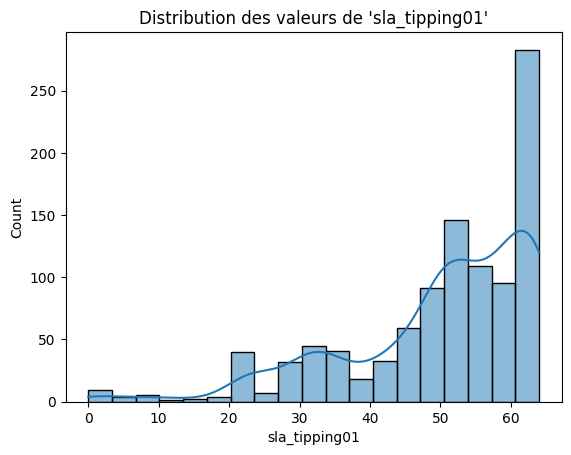

In [94]:
dftipping = df[df["sla_tipping01"]==10][["sla_tipping01", "combined_column"]].drop_duplicates()
dftipping.reset_index(drop=True, inplace=True)
print("LIST", dftipping.to_string(index=True))
print()

import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que votre DataFrame s'appelle df
# Afficher la distribution des valeurs de la colonne 'sla_tipping01'
tipping_per_workload = df.groupby('combined_column')['sla_tipping01'].first()
sns.histplot(tipping_per_workload, kde=True)

# Ajouter un titre
plt.title("Distribution des valeurs de 'sla_tipping01'")

# Afficher le graphique
plt.show()

In [104]:
workload = "V10 40 1.0 12 Un" # 64"V12.3 22 1.0 1 Ga" #63"V10 50 1.0 3 Pa" #62"V9 40 0.3 2 Ga" #0"V10 40 1.0 12 Un" #2"V9 40 1.0 12 Un" #10"V10 40 1.0 7 Un
#df[df["combined_column"]==workload]["sla_tipping01"].tolist()
#df[df["combined_column"]==workload]["buf_size_idx"].tolist()


new_columns = ["OP_USLA", "OP_CRAM", "OP_OB_CRAM", "OP_OB_USLA"]
df.loc[df["combined_column"]==workload, "buf_size_mb"] = df.apply(lambda row: int(row["buf_size"])/1024/1024 , axis=1)
#df.loc[df["combined_column"]==workload, new_columns] = df.apply(lambda row: computeOptimalPolicyPerformance(row, new_columns), axis=1) #, result_type='expand' )
df.loc[df["combined_column"]==workload, "OP_USLA"] = df.apply(lambda row: compute_OP_USLA(int(row["buf_size_idx"]), int(row["sla_tipping01"])), axis=1) 
df.loc[df["combined_column"]==workload, "OP_CRAM"] = df.apply(lambda row: compute_OP_CRAM(int(row["sla_tipping01"]), int(row["buf_size_idx"])), axis=1) 
df.loc[df["combined_column"]==workload, "OP_OB_CRAM"] = df.apply(lambda row: compute_OP_OVER_BUDGET_CRAM(int(row["sla_tipping01"])), axis=1)
df.loc[df["combined_column"]==workload, "OP_OB_USLA"] = df.apply(lambda row: compute_OP_OVER_BUDGET_USLA(int(row["sla_tipping01"])), axis=1)

#df.loc[df["combined_column"]==workload, "buf_size_idx","OP_USLA"]
dfresults = df[df["combined_column"]==workload][["buf_size_idx","sla_tipping01", "buf_size_mb", "sysbench_filtered.latency_mean"]+new_columns]
dfresults.reset_index(drop=True, inplace=True)
print(dfresults.to_string(index=True))

    buf_size_idx  sla_tipping01  buf_size_mb  sysbench_filtered.latency_mean  OP_USLA   OP_CRAM  OP_OB_CRAM  OP_OB_USLA
0             63            0.0       8192.0                       28.462768      1.0   16384.0      8192.0         1.0
1             62            0.0       8064.0                       28.218911      2.0   16256.0      8192.0         1.0
2             61            0.0       7936.0                       27.975054      3.0   24192.0      8192.0         1.0
3             60            0.0       7808.0                       27.853125      4.0   32000.0      8192.0         1.0
4             59            0.0       7680.0                       29.408750      5.0   39680.0      8192.0         1.0
5             58            0.0       7552.0                       30.949583      6.0   47232.0      8192.0         1.0
6             57            0.0       7424.0                       22.106563      7.0   54656.0      8192.0         1.0
7             56            0.0       72